In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from polars import selectors as cs
from sklearn.model_selection import train_test_split
from typing import cast

sys.path.append(r"../baseline_v2")
from add_features import add_modified_features
from load_data import load_data
from preprocess import build_preprocessor, build_target_transformer

%matplotlib inline

warnings.filterwarnings('ignore')

### load

In [3]:
train, test = load_data()
X = train.copy()
# y = X.pop('SalePrice')
X_test = test.copy()
X.shape, X_test.shape

((1458, 80), (1459, 79))

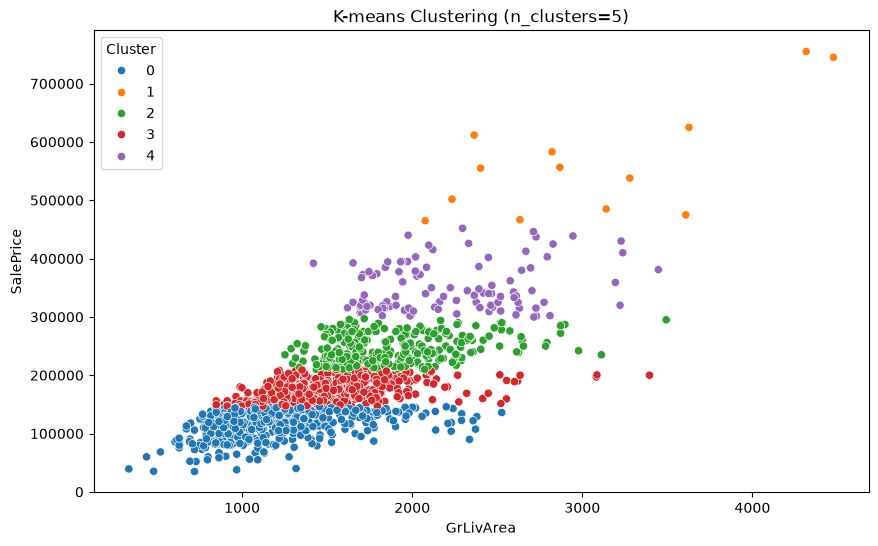

In [4]:
from sklearn.cluster import KMeans

# データの準備
df_cluster = X[['GrLivArea', 'SalePrice']].dropna()

# K-meansモデルの学習と予測
kmeans = KMeans(n_clusters=5, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(df_cluster)

# 結果の可視化
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x='GrLivArea',
    y='SalePrice',
    hue='Cluster',
    palette='tab10'
)
plt.title('K-means Clustering (n_clusters=5)')
plt.show()